In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import OPTICS
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 10.Clusstering_OPTICS_Algorithms

In [5]:
df = df.drop(columns='CustomerID')

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


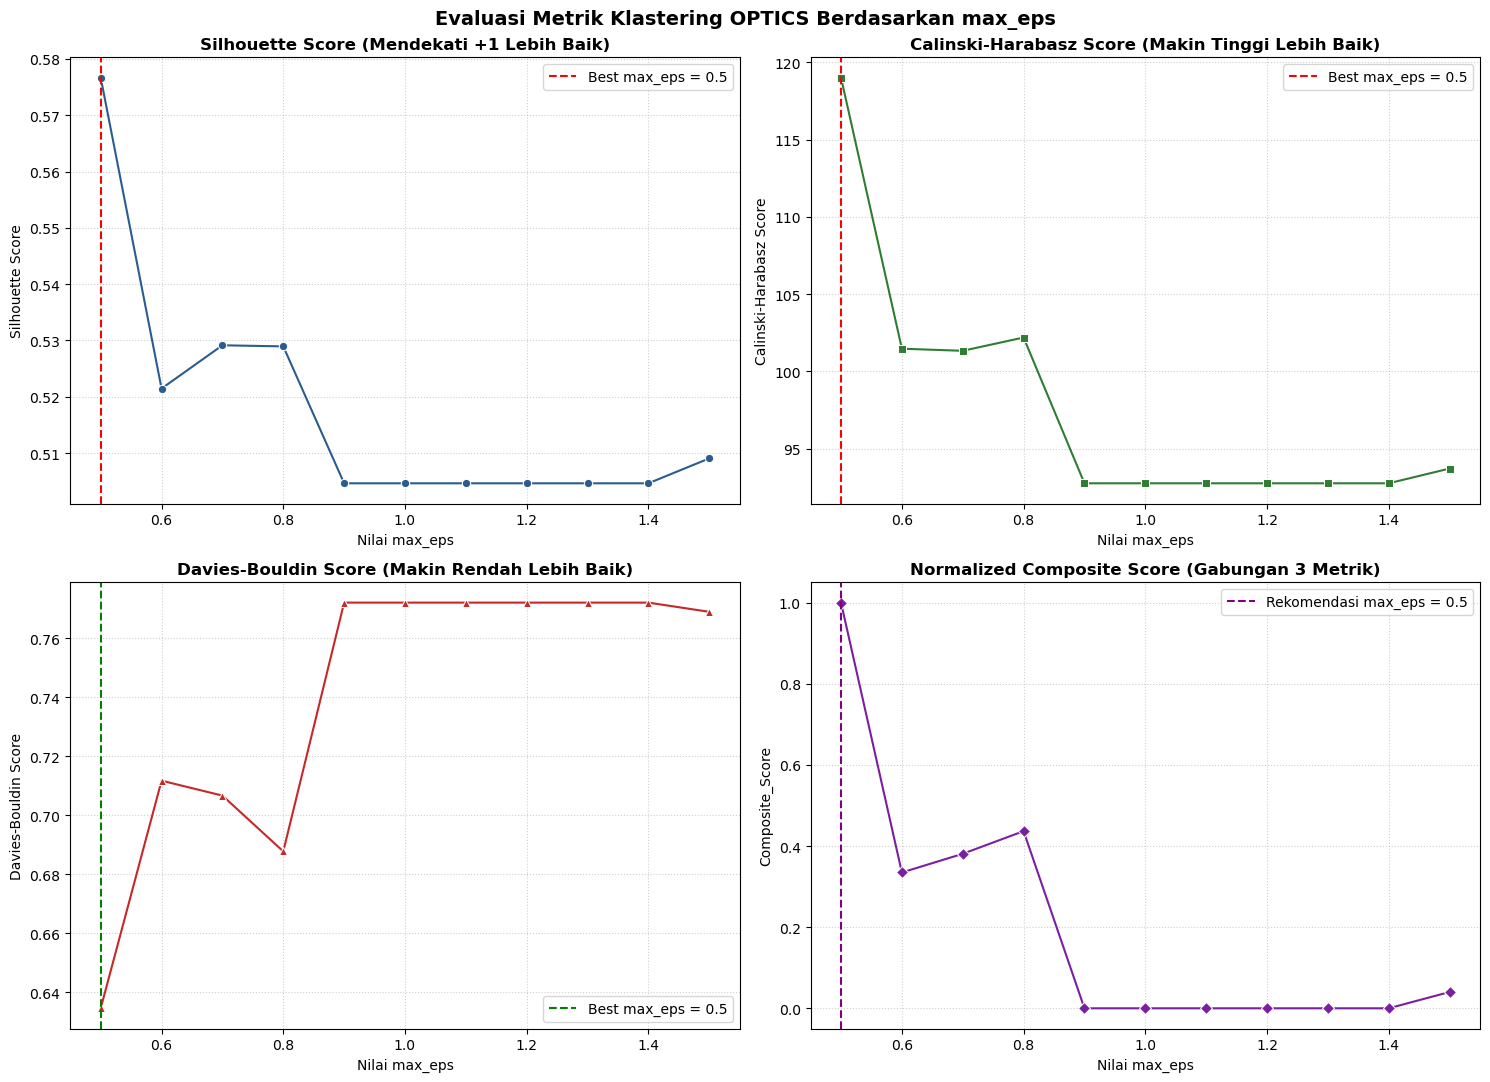

In [ ]:
X_arr = X_cleaned.values if isinstance(X_cleaned, pd.DataFrame) else X_cleaned

# Testing rentang max_eps
eps_range = np.arange(0.1, 1.6, 0.1)

eps_values = []
sil_scores = []
ch_scores = []
db_scores = []
n_clusters_found = []

for eps in eps_range:
    optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05, max_eps=eps)
    labels = optics.fit_predict(X_arr)
    
    core_mask = labels != -1
    unique_labels = set(labels[core_mask])
    
    if len(unique_labels) >= 2:
        X_valid = X_arr[core_mask]
        labels_valid = labels[core_mask]
        
        eps_values.append(round(eps, 2))
        sil_scores.append(silhouette_score(X_valid, labels_valid))
        ch_scores.append(calinski_harabasz_score(X_valid, labels_valid))
        db_scores.append(davies_bouldin_score(X_valid, labels_valid))
        n_clusters_found.append(len(unique_labels))

df_scores = pd.DataFrame({
    'Clusters Found': n_clusters_found,
    'eps': eps_values,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})

if not df_scores.empty:
    scaler = MinMaxScaler()
    norm_sil = scaler.fit_transform(df_scores[['Silhouette Score']])
    norm_ch = scaler.fit_transform(df_scores[['Calinski-Harabasz Score']])
    norm_db = 1 - scaler.fit_transform(df_scores[['Davies-Bouldin Score']])
    df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # --- Plot 1: Silhouette Score ---
    best_idx_sil = df_scores['Silhouette Score'].idxmax()
    best_eps_sil = df_scores.loc[best_idx_sil, 'eps']
    sns.lineplot(ax=axes[0, 0], x='eps', y='Silhouette Score', data=df_scores, marker='o', color='#2b5c8f')
    axes[0, 0].axvline(x=best_eps_sil, color='red', linestyle='--', label=f'Best max_eps = {best_eps_sil}')
    axes[0, 0].set_title('Silhouette Score (Mendekati +1 Lebih Baik)', fontweight='bold')
    axes[0, 0].set_xlabel('Nilai max_eps')
    axes[0, 0].grid(True, linestyle=':', alpha=0.6)
    axes[0, 0].legend()

    # --- Plot 2: Calinski-Harabasz Score ---
    best_idx_ch = df_scores['Calinski-Harabasz Score'].idxmax()
    best_eps_ch = df_scores.loc[best_idx_ch, 'eps']
    sns.lineplot(ax=axes[0, 1], x='eps', y='Calinski-Harabasz Score', data=df_scores, marker='s', color='#2e7d32')
    axes[0, 1].axvline(x=best_eps_ch, color='red', linestyle='--', label=f'Best max_eps = {best_eps_ch}')
    axes[0, 1].set_title('Calinski-Harabasz Score (Makin Tinggi Lebih Baik)', fontweight='bold')
    axes[0, 1].set_xlabel('Nilai max_eps')
    axes[0, 1].grid(True, linestyle=':', alpha=0.6)
    axes[0, 1].legend()

    # --- Plot 3: Davies-Bouldin Score ---
    best_idx_db = df_scores['Davies-Bouldin Score'].idxmin()
    best_eps_db = df_scores.loc[best_idx_db, 'eps']
    sns.lineplot(ax=axes[1, 0], x='eps', y='Davies-Bouldin Score', data=df_scores, marker='^', color='#c62828')
    axes[1, 0].axvline(x=best_eps_db, color='green', linestyle='--', label=f'Best max_eps = {best_eps_db}')
    axes[1, 0].set_title('Davies-Bouldin Score (Makin Rendah Lebih Baik)', fontweight='bold')
    axes[1, 0].set_xlabel('Nilai max_eps')
    axes[1, 0].grid(True, linestyle=':', alpha=0.6)
    axes[1, 0].legend()

    # --- Plot 4: Composite Score ---
    best_idx_comp = df_scores['Composite_Score'].idxmax()
    best_eps_comp = df_scores.loc[best_idx_comp, 'eps']
    sns.lineplot(ax=axes[1, 1], x='eps', y='Composite_Score', data=df_scores, marker='D', color='#7b1fa2')
    axes[1, 1].axvline(x=best_eps_comp, color='purple', linestyle='--', label=f'Rekomendasi max_eps = {best_eps_comp}')
    axes[1, 1].set_title('Normalized Composite Score (Gabungan 3 Metrik)', fontweight='bold')
    axes[1, 1].set_xlabel('Nilai max_eps')
    axes[1, 1].grid(True, linestyle=':', alpha=0.6)
    axes[1, 1].legend()

    plt.suptitle('Evaluasi Metrik Klastering OPTICS Berdasarkan max_eps', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada kombinasi yang menghasilkan minimal 2 cluster non-noise.")

In [8]:
dim = X_cleaned.shape[1]
min_samples_val = 2 * dim
epsilon = 0.7 

best_optics = OPTICS(min_samples=min_samples_val, max_eps=epsilon, xi=0.05, min_cluster_size=0.05)

df['Cluster'] = best_optics.fit_predict(X_cleaned)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,-1
1,Male,21,15,81,-1
2,Female,20,16,6,-1
3,Female,23,16,77,-1
4,Female,31,17,40,-1


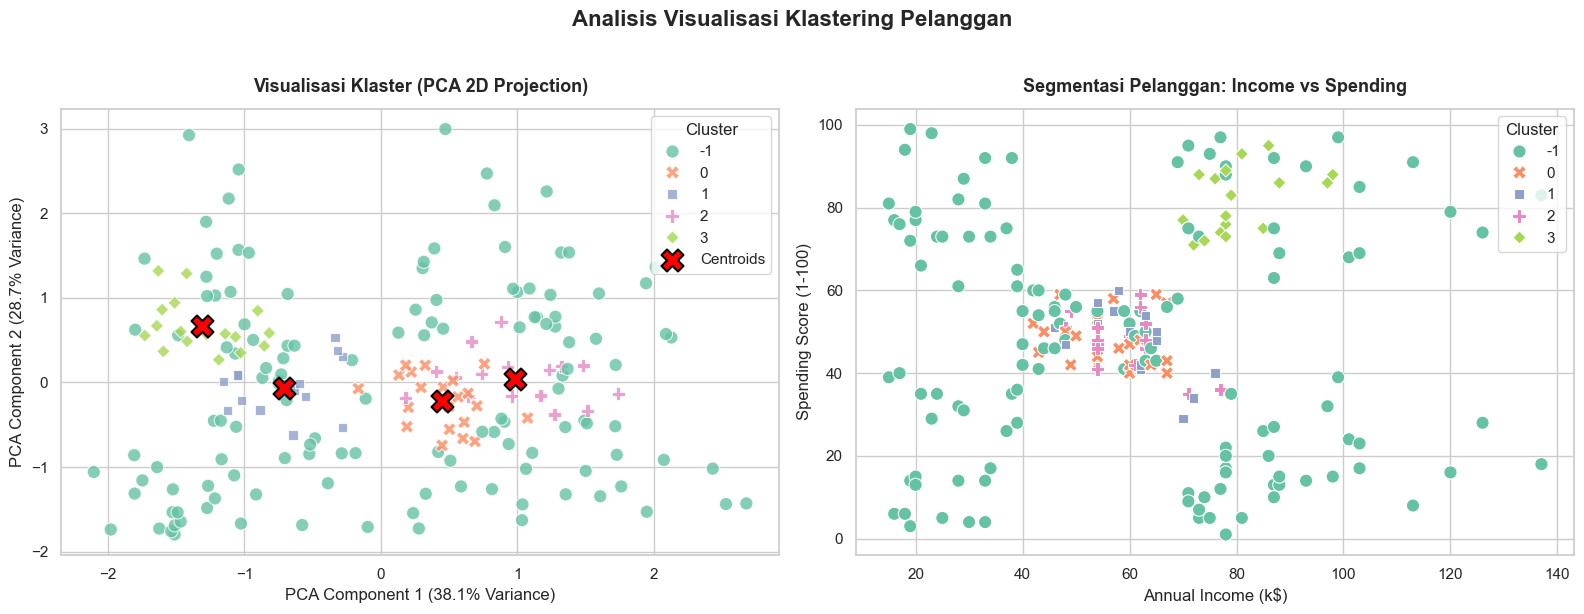

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster'].values
valid_clusters = df_pca[df_pca['Cluster'] != -1]
centroids_pca = valid_clusters.groupby('Cluster')[['PCA1', 'PCA2']].mean().values

sns.set_theme(style="whitegrid")
palette = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid
axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Cluster', loc='upper right')

sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,  palette=palette, s=90, style='Cluster')
axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(title='Cluster', loc='upper right')

plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

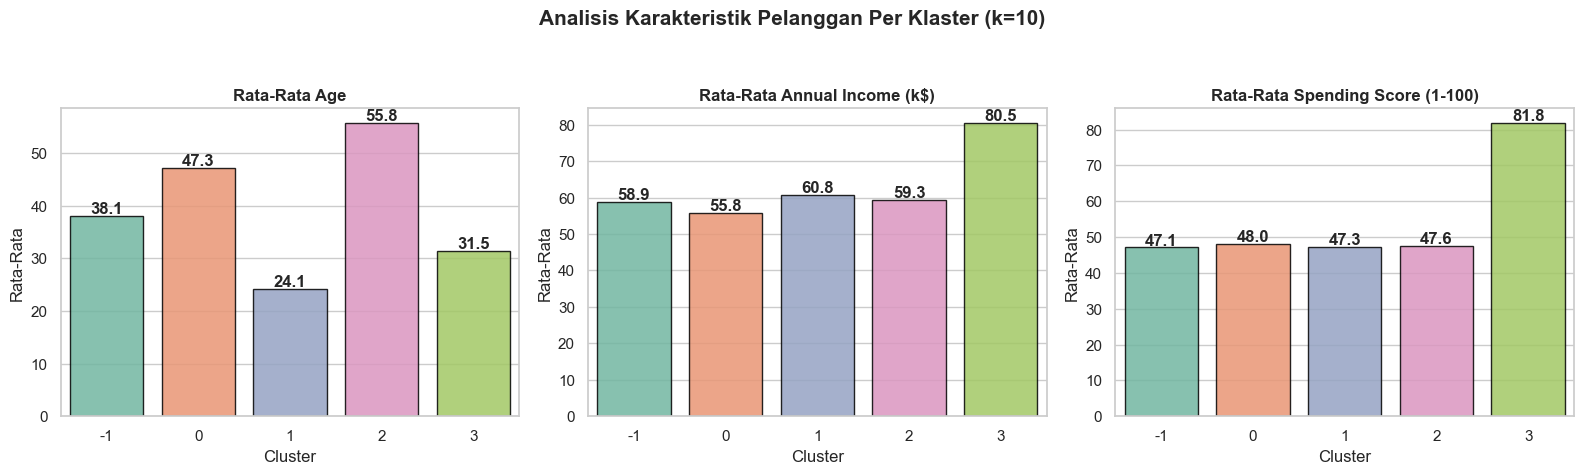

In [10]:
df_profile = df.groupby('Cluster')[num_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=palette, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-Rata')
    for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
        axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle(f'Analisis Karakteristik Pelanggan Per Klaster (k={min_samples_val})', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()